**1. Import Libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import seaborn as sns

**2. Mount Colab to Drive**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**3. Import Dataset**

In [3]:
file_path = '/content/drive/MyDrive/Analisis/dataset_levelearn_heart.csv'

data = pd.read_csv(file_path, encoding='latin-1')
data.head(10)

,Timestamp,Email,Nama,NIM,Angkatan,Happiness_Q1,Happiness_Q2,Happiness_Q3,Happiness_Q4,Happiness_Q5,...,TaskSuccess_Q10,TaskSuccess_Q11,TaskSuccess_Q12,Qualitative_Q1,Qualitative_Q2,Qualitative_Q3,Qualitative_Q4,Feedback,Error,Suggestion
0,03/03/2026 13:23:48,christopasaribu90@gmail.com,Christo Pasaribu,11S23005,2023,5,5,5,5,5,...,4,4,4,"badge, saya terdorong untuk mengumpulkan lebih...",tidak,berguna semua,lebih terdorong setelah gamifikasi di terapkan,aplikasi sudah sangat bagus,tidak ada temuan error selama menggunakan apli...,ada hadiah yang lebih menarik
1,03/03/2026 13:24:39,samuelsibarani2510@gmail.com,Samuel faldhieto sibarani,11S23038,2023,5,5,5,5,5,...,5,5,5,Elemen dashboard karena membuat saya ingin men...,Tidak,Tidak,Menjadi lebih rajin karena belajar sambil berm...,Coba untuk menambahkan lagi fitur profile kara...,Tidak ada,Sudah baik
2,03/03/2026 13:24:58,christiaxxr@gmail.com,Christian Johannes Hutahaean,11S23036,2023,5,5,5,5,5,...,5,4,5,Leadboard,Tidak,Tidak ada,Sangat membantu dalam meningkatkan semangat be...,-,-,-
3,03/03/2026 13:24:59,ivanapasaribu17@gmail.com,Sri Intan Ivana Pasaribu,11S23006,2023,4,4,4,4,4,...,4,4,4,streak karena menantang,tidak,tidak,sesudah membjat lebih belajar karena ada metod...,sudah sangat baik,bagian essay jawabannya harus sama oersis biar...,jawaban essay tolong dikembangkan ya kak/bang
4,03/03/2026 13:25:00,joey.cristo05@gmail.com,Joey Cristo Thruli,11S23012,2023,5,5,5,5,5,...,5,5,5,Streak,Tidak,Menurut saya semuanya berguna dan bermanfaat. ...,"Karena gamifikasi yang diterapkan, saya merasa...","Aplikasi sudah bagus, penggunaan warna juga sa...",tidak ada,menurut saya elemen gamifikasinya dapat diting...
5,03/03/2026 13:25:41,danieltbg145@gmail.com,Daniel L. Tobing,11S23025,2023,4,4,4,5,5,...,5,5,5,Adanya sistwm rank,Tidak,"Ada, fitur ranknya jadi siapa yang cepat menja...",Lebih menarik dan tertantang,Aplikasi menarik dan menantang mahasiswa untuk...,Tidak ada untuk saat ini,Adanya fitur siapa paling cepat mejawab oertan...
6,03/03/2026 13:25:42,andresaragih932@gmail.com,Andre Christian Saragih,11S23026,2023,4,5,4,5,4,...,5,5,5,elemen leaderboard jadi memotifasi saya dalam ...,"Sudah baik, tidak usah",Semua Baik,Menjadi lebih mudah memahami,Sudah baik,sejauh ini baik,sudah baik
7,03/03/2026 13:26:02,marshallmanurung92@gmail.com,MARSHALL MANURUNG,11S23021,2023,4,4,5,4,4,...,5,4,5,Materi lebih ringkas(to the point) jadi lebih ...,Tidak,ga ada,sebelum menggunakan gamifikasi pembelajaran su...,Sangat bagus dan menarik untuk digunakan jangk...,"Mungkin lebih ke jawaban essay,, (karena essay...",Mungkin bisa dibuat kembali ke soal sebelumnya...
8,03/03/2026 13:26:17,gloriapanjaitan3012@gmail.com,Gloria Panjaitan,11S23030,2023,5,5,5,5,5,...,5,4,4,Poin karena seolah punya uang,Tidak,Tidak,Lebih seru dengan gamifikasi,"Bagus, silahkan ditingkatkan kak bang",Temuan bug saya pada aplikasi yaitu progres ba...,Butuh suara yang unik untuk aksi misalnya meny...
9,03/03/2026 13:26:24,yuripakpahan2205@gmail.com,Yuri Pakpahan,11S23051,2023,4,4,4,4,4,...,4,4,4,"Ranking, karena memberi rasa kompetitif",Tidak,Tidak,Saya lebih senang menggunakan aplikasi belajar...,Sudah bagus,Tidak ada,Sudah baik


**4. Data Pre-Processing**

**4.1 CEK DAN TANGANI DUPLIKASI DATA**

In [4]:
metrics = ['Happiness', 'Engagement', 'Adoption', 'Retention', 'TaskSuccess']
likert_columns = [f"{metric}_Q{i}" for metric in metrics for i in range(1, 13)]

print(f"Jumlah baris sebelum hapus duplikat: {data.shape[0]}")
data = data.drop_duplicates(subset=['NIM'], keep='last').copy()
print(f"Jumlah baris setelah hapus duplikat: {data.shape[0]}\n")

df_likert = data[likert_columns].astype(float)
df_likert["Total_Score"] = df_likert.sum(axis=1)

Jumlah baris sebelum hapus duplikat: 54
Jumlah baris setelah hapus duplikat: 54



**4.2 CEK DAN TANGANI MISSING VALUES (NaN)**

In [5]:
missing_values = df_likert.isnull().sum().sum()
print(f"Total missing values di kolom Likert: {missing_values}")

if missing_values > 0:
    # Menghapus baris yang memiliki nilai kosong
    df_likert = df_likert.dropna()
    # Menyesuaikan kembali data utama agar jumlah barisnya sama
    data = data.loc[df_likert.index]
    print("Baris dengan missing values telah dihapus.\n")
else:
    print("Tidak ada missing values yang ditemukan.\n")

Total missing values di kolom Likert: 0
Tidak ada missing values yang ditemukan.



**4.3 DETEKSI OUTLIER (STRAIGHT-LINING)**

In [6]:
df_likert['Std_Dev'] = df_likert[likert_columns].std(axis=1)
straight_liners = df_likert[df_likert['Std_Dev'] == 0]
print(f"Jumlah responden terindikasi straight-lining (nilai konstan): {len(straight_liners)}\n")

Jumlah responden terindikasi straight-lining (nilai konstan): 5



**4.4 FEATURE ENGINEERING: SKOR PER DIMENSI HEART**

In [7]:
df_likert['Happiness_Avg'] = df_likert[[col for col in likert_columns if 'Happiness' in col]].mean(axis=1)
df_likert['Engagement_Avg'] = df_likert[[col for col in likert_columns if 'Engagement' in col]].mean(axis=1)
df_likert['Adoption_Avg'] = df_likert[[col for col in likert_columns if 'Adoption' in col]].mean(axis=1)
df_likert['Retention_Avg'] = df_likert[[col for col in likert_columns if 'Retention' in col]].mean(axis=1)
df_likert['TaskSuccess_Avg'] = df_likert[[col for col in likert_columns if 'TaskSuccess' in col]].mean(axis=1)

df_final = pd.concat([data[['Nama', 'NIM']], df_likert], axis=1)

df_final.head()

,Nama,NIM,Happiness_Q1,Happiness_Q2,Happiness_Q3,Happiness_Q4,Happiness_Q5,Happiness_Q6,Happiness_Q7,Happiness_Q8,...,TaskSuccess_Q10,TaskSuccess_Q11,TaskSuccess_Q12,Total_Score,Std_Dev,Happiness_Avg,Engagement_Avg,Adoption_Avg,Retention_Avg,TaskSuccess_Avg
0,Christo Pasaribu,11S23005,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,...,4.0,4.0,4.0,294.0,0.302532,5.0,5.0,5.0,5.000000,4.500000
1,Samuel faldhieto sibarani,11S23038,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,...,5.0,5.0,5.0,300.0,0.000000,5.0,5.0,5.0,5.000000,5.000000
2,Christian Johannes Hutahaean,11S23036,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,...,5.0,4.0,5.0,293.0,0.323732,5.0,5.0,5.0,5.000000,4.416667
3,Sri Intan Ivana Pasaribu,11S23006,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,...,4.0,4.0,4.0,249.0,0.360085,4.0,4.0,4.0,4.416667,4.333333
4,Joey Cristo Thruli,11S23012,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,...,5.0,5.0,5.0,300.0,0.000000,5.0,5.0,5.0,5.000000,5.000000


**5. Reliability Test using Crobach's Alpha**

In [14]:
aspek_list = ['Happiness', 'Engagement', 'Adoption', 'Retention', 'Task Success']

print("--- Hasil Cronbach's Alpha per Aspek ---")

for aspek in aspek_list:
    search_term = aspek.replace(" ", "")
    cols_aspek = [col for col in likert_columns if search_term in col]

    if len(cols_aspek) > 1:
        alpha_aspek = cronbach_alpha(df_likert[cols_aspek])

        print(f"Cronbach's Alpha for {aspek:12}: {alpha_aspek:.3f}")
    else:
        print(f"Cronbach's Alpha for {aspek:12}: Data tidak mencukupi")

--- Hasil Cronbach's Alpha per Aspek ---
Cronbach's Alpha for Happiness   : 0.902
Cronbach's Alpha for Engagement  : 0.936
Cronbach's Alpha for Adoption    : 0.923
Cronbach's Alpha for Retention   : 0.924
Cronbach's Alpha for Task Success: 0.898


**6. Visualisasi Reliabilitas**

/tmp/ipykernel_486/3415070270.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=aspek_names, y=alpha_per_aspek, palette="viridis")


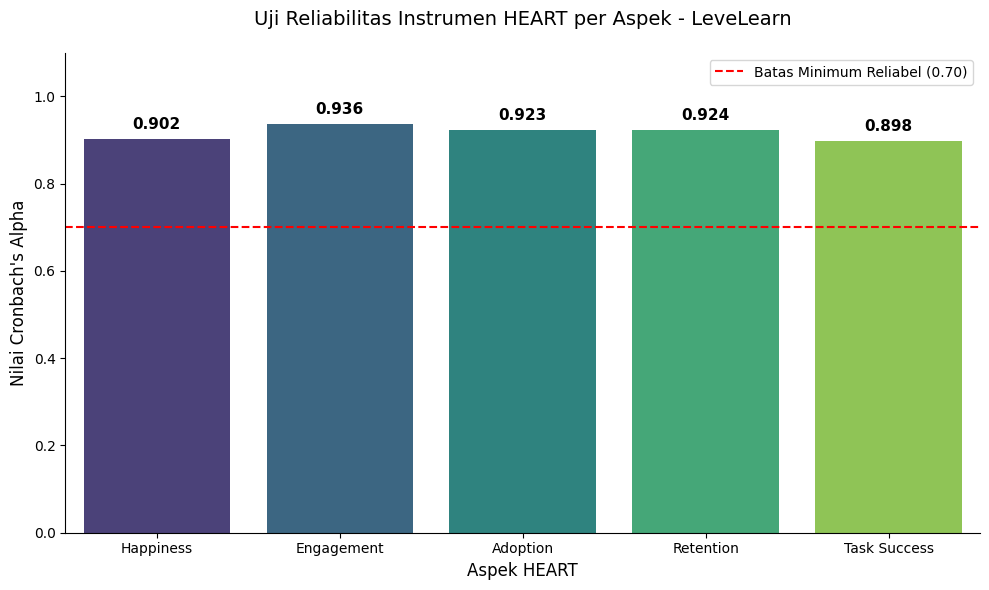

In [13]:
aspek_list = ['Happiness', 'Engagement', 'Adoption', 'Retention', 'Task Success']
aspek_names = []
alpha_per_aspek = []

for aspek in aspek_list:
    search_term = aspek.replace(" ", "")
    cols_aspek = [col for col in likert_columns if search_term in col]

    if len(cols_aspek) > 1:
        alpha = cronbach_alpha(df_likert[cols_aspek])
        aspek_names.append(aspek)
        alpha_per_aspek.append(alpha)

plt.figure(figsize=(10, 6))

ax = sns.barplot(x=aspek_names, y=alpha_per_aspek, palette="viridis")

plt.ylim(0, 1.1)
plt.title("Uji Reliabilitas Instrumen HEART per Aspek - LeveLearn", fontsize=14, pad=20)
plt.ylabel("Nilai Cronbach's Alpha", fontsize=12)
plt.xlabel("Aspek HEART", fontsize=12)

plt.axhline(y=0.70, color='red', linestyle='--', label='Batas Minimum Reliabel (0.70)')
plt.legend(loc='upper right')

for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold', color='black',
                xytext=(0, 5), textcoords='offset points')

plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()

plt.show()

/tmp/ipykernel_486/486551608.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=["Cronbach's Alpha"], y=[alpha_value], palette="Blues")


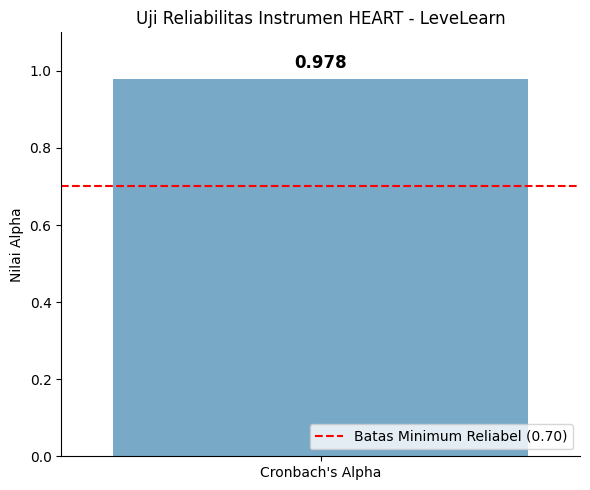

np.float64(0.9779248597797834)

In [15]:
plt.figure(figsize=(6, 5))

ax = sns.barplot(x=["Cronbach's Alpha"], y=[alpha_value], palette="Blues")
plt.ylim(0, 1.1)
plt.title("Uji Reliabilitas Instrumen HEART - LeveLearn")
plt.ylabel("Nilai Alpha")

plt.axhline(y=0.70, color='red', linestyle='--', label='Batas Minimum Reliabel (0.70)')
plt.legend(loc='lower right')

for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black',
                xytext=(0, 5), textcoords='offset points')

plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

alpha_value